In [1]:
from diff_sampling_env import DiffSamplingEnv

import torch
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np


batch_size = 2048
num_steps = 1000
env = DiffSamplingEnv(
    batch_size=batch_size,
    reward_func='grad_norm'
)
env.reset() # batch_seeds=torch.randint(low=0, high=1000, size=(batch_size,))
# img = env.sample_via_sample_fn()
done = False
rs = []
obses = []
preds = []
rev_discount = 0.9
while not done:
    obs, r, done, info = env.step(np.vstack([-1 * np.ones(batch_size), np.zeros(batch_size)]).T)
    rs.append(r.cpu().numpy())
    obses.append(obs.cpu().numpy())
    preds.append(info['pred_cur'].cpu().numpy())
    done = torch.any(done)
print(env.current_step, done)
obses = np.array(obses)[:, :, :2]
generated = obs.cpu().numpy()[:, :2]
preds = np.array(preds)
preds.shape
rs = np.array(rs)

19 tensor(True, device='cuda:0')


In [20]:
rs.shape

(19, 2048)

(array([  45,  786,  995, 1058, 1450, 1482]),)


Text(0.5, 1.0, 'predicted $x_0$ for not in-context samples')

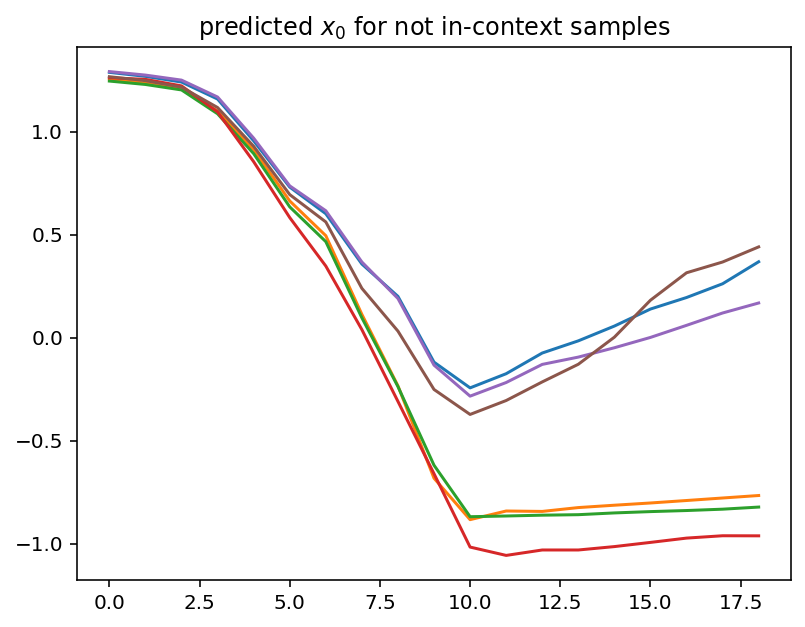

In [2]:
obses.shape
idx = np.all(np.abs(generated) < 1., axis=1)
print(np.nonzero(idx))
filtered = preds[:, idx]
for i in range(filtered.shape[1]):
    plt.plot(filtered[:, i, 0])
# filtered[:, 0]
plt.title(r'predicted $x_0$ for not in-context samples')


[False False False ... False False False]


Text(0.5, 1.0, 'predicted $x_0$ for in-context samples')

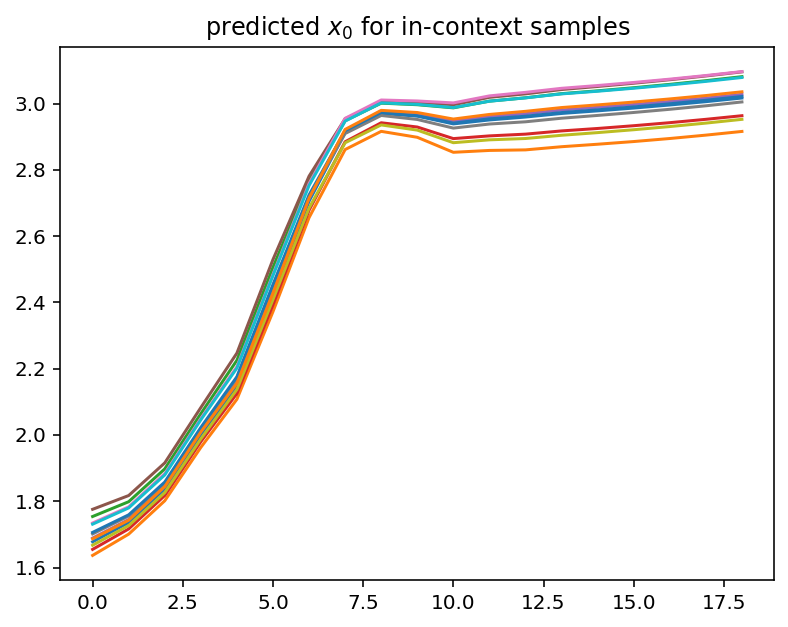

In [6]:
idx = np.all(np.abs(generated - 3.) < 0.1, axis=1)
print(idx)
filtered = preds[:, idx]
for i in range(filtered.shape[1]):
    plt.plot(filtered[:, i, 0],)
    
plt.title(r'predicted $x_0$ for in-context samples')
# filtered[:, 0]
# print(rs[:, idx])

[False False False ... False False False]


Text(0.5, 1.0, 'predicted $x_0$ for in-context samples')

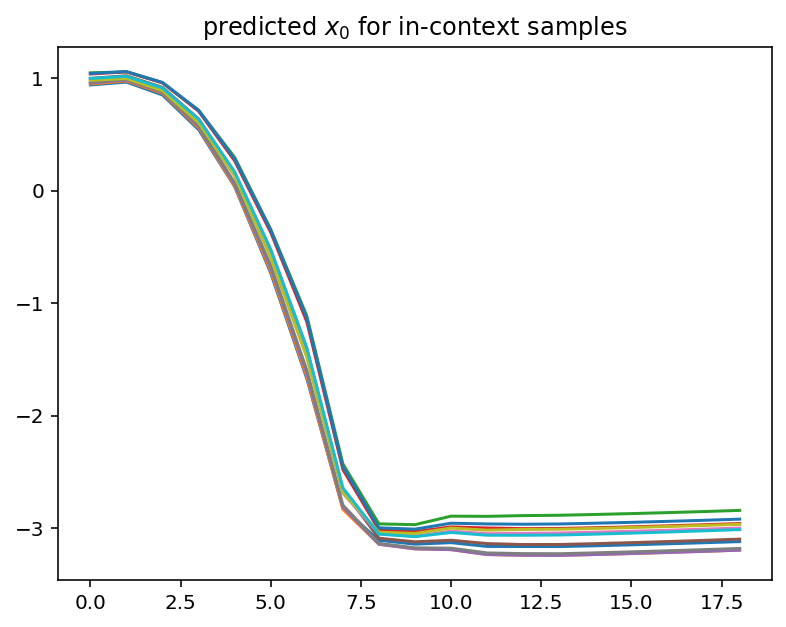

In [7]:
idx = np.all(np.abs(generated + 3.) < 0.2, axis=1)
print(idx)
filtered = preds[:, idx]
for i in range(filtered.shape[1]):
    plt.plot(filtered[:, i, 0],)

plt.title(r'predicted $x_0$ for in-context samples')


[15.001019 74.784256 25.847494 ... 23.642536 54.29126  32.853146]


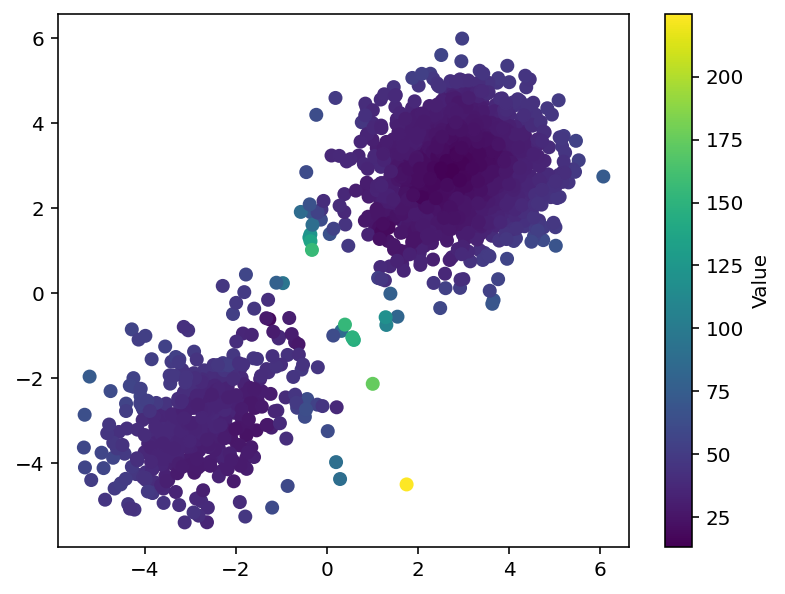

In [3]:
sum = np.sum(rs, axis=0)
# plt.plot(rs)
# var = np.array(rs).sum(axis=0)
# plt.show()


var = np.var(obses, axis=0).mean(axis=-1)
print(var)
scatter = plt.scatter(generated[:, 0], generated[:, 1], c=sum, )
cbar = plt.colorbar(scatter)
cbar.set_label('Value')
plt.show()

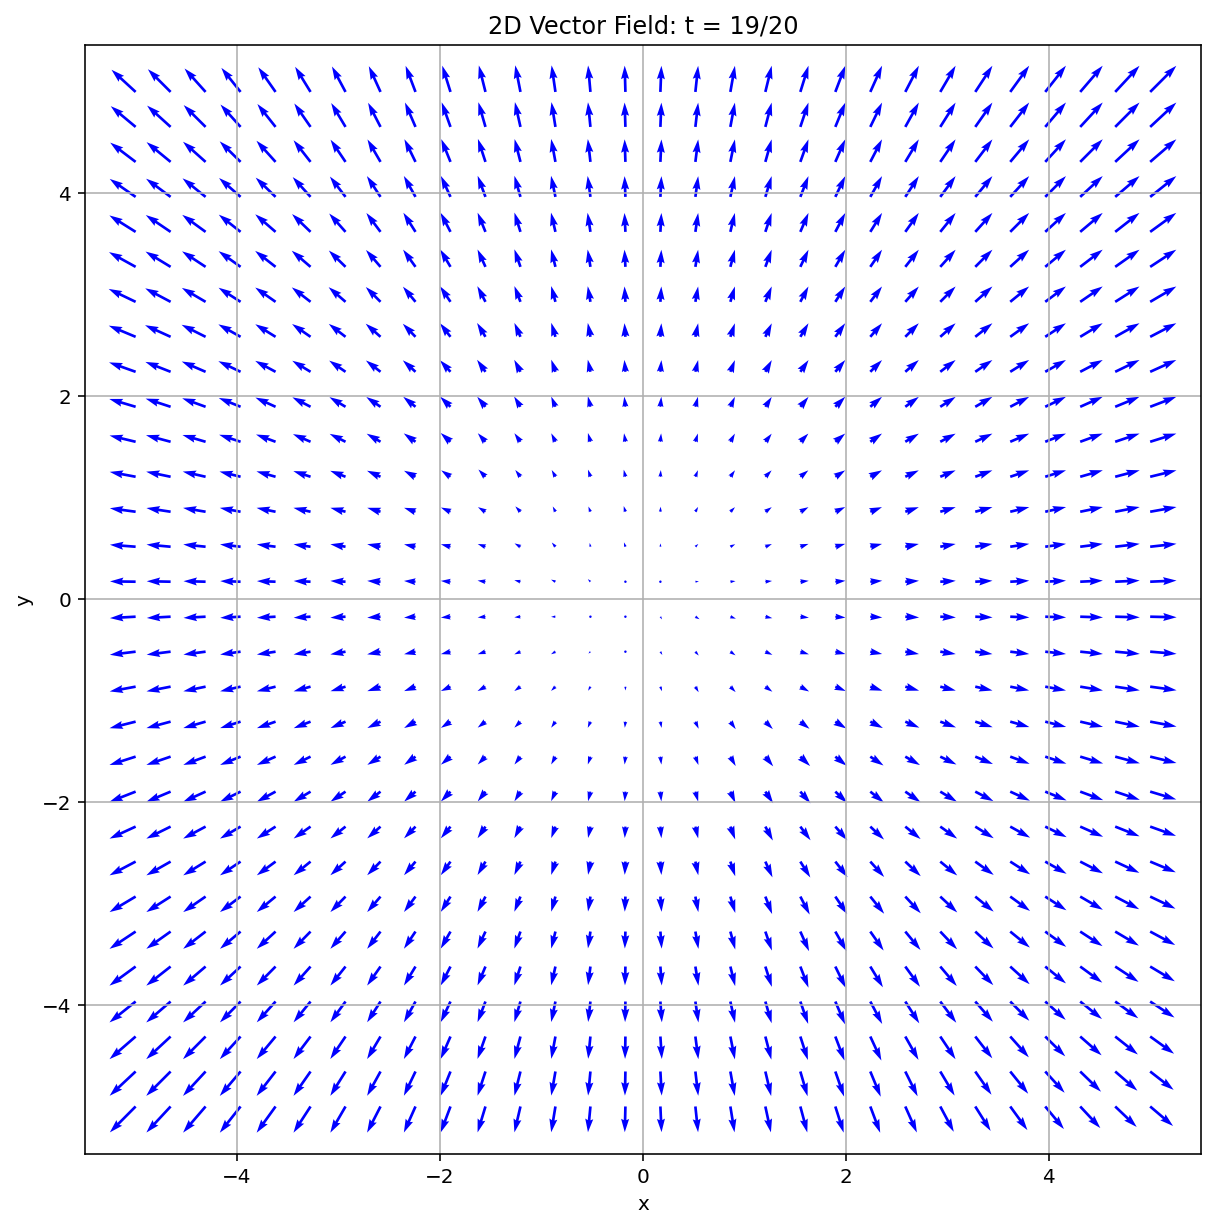

In [31]:
# Define the grid
# x = np.linspace(-30, 30, 30)
# y = np.linspace(-30, 30, 30)
x = np.linspace(-5, 5, 30)
y = np.linspace(-5, 5, 30)
X, Y = np.meshgrid(x, y)

# Define the vector field function F(x, y) = (-y, x)
input = torch.from_numpy(np.vstack([X.ravel(), Y.ravel()]).T).float().to(env.device)
idx = 19
t = env.t_steps[idx]
x_pred = env.net(input, t * torch.ones([900, 1]).to(env.device))
d = -(input - x_pred / t)
U = d[:, 0].reshape(X.shape)
V = d[:, 1].reshape(Y.shape)
U = U.cpu().detach().numpy()
V = V.cpu().detach().numpy()

# Plot the vector field
plt.figure(figsize=(10, 10))
plt.quiver(X, Y, U, V, color='blue')
plt.title('2D Vector Field: t = {}/20'.format(idx))
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()

In [13]:
input = torch.from_numpy(np.vstack([X.ravel(), Y.ravel()]).T).float().to(env.device)
t = env.t_steps[0]
x_pred = env.net(input, t * torch.ones([900, 1]).to(env.device))
d = input - x_pred / t
U = d[:, 0].reshape(X.shape)
V = d[:, 1].reshape(Y.shape)

torch.Size([900, 2])